<a href="https://colab.research.google.com/github/brendanperez/PHY386/blob/brendanperez-final/2026/FinalProject/brendanperez/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/FinalProject/Final_03_MethaneCH4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project — Topic 3: Atmospheric Methane (CH₄) Forecast (42 pts)
## The regression / time-series stretch

## Learning Outcomes
- Decompose a real climate time series into trend, seasonal, and residual components.
- Fit physically motivated models (linear, quadratic, Fourier-series seasonal) with `scipy.optimize.curve_fit` and report parameter uncertainties.
- Extrapolate a regression model with a **quantified confidence band** — not just a point forecast.
- Recognize when a simple model fails (here: the 1999–2006 methane plateau) and address it with a piecewise or change-point model.
- Compare a purely statistical machine-learning approach (sklearn `MLPRegressor` on lagged features) with the physically motivated fit.

## GitHub Workflow
Fork → `yourname-final` → PR into `Homework2026`. Reviewer `@laserlab`, milestone `Final-2026`.

## Why this topic is the "stretch"
HW5 and HW6 covered **classification** only. Here you'll work on **regression on a time series**, which requires a different metric set (root-mean-square error, prediction intervals — not confusion matrices) and different diagnostics (residual plots, autocorrelation). That's the point: you'll pick up new methodology on top of the HW5/HW6 toolkit.

## Background: Atmospheric Methane

Methane (CH₄) is the second-most-important long-lived greenhouse gas after CO₂. Per molecule, it's roughly **80× more potent than CO₂ as a climate forcer over a 20-year horizon**, though it has a much shorter atmospheric lifetime (~10 yr vs. centuries for CO₂).

The NOAA Global Monitoring Laboratory (GML) publishes a **globally-averaged marine-surface** methane record going back to **July 1983**. The time series has three physically distinct features you will model:

1. **Long-term trend** — driven by the global source minus sink balance. Not a clean linear rise:
   - ~1983–1999: rapid rise (~12 ppb/yr).
   - **~1999–2006: plateau** — sources and sinks roughly balanced. The physics is still debated: shifts in wetland emissions, tropical biosphere response, perhaps changes in OH-radical concentration.
   - **~2007–present: renewed rise**, accelerating sharply around **2020**.
2. **Seasonal cycle** — CH₄ has a small (~10 ppb peak-to-peak) annual cycle driven by photochemical oxidation by OH in summer.
3. **Inter-annual variability** — the residual after removing trend and seasonal, visibly correlated with El Niño.

A student who naively fits a single polynomial to this series and extrapolates will get 2030 catastrophically wrong. Diagnosing *why* is the core learning outcome.

In [ ]:
# Required packages (uncomment for Colab or fresh environment):
%pip install pandas scipy statsmodels scikit-learn --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 11, 'axes.titlesize': 11,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
})

## Worked Example: Load the NOAA GML Methane Record

In [ ]:
URL = "https://gml.noaa.gov/webdata/ccgg/trends/ch4/ch4_mm_gl.txt"
df = pd.read_csv(
    URL,
    comment="#",
    sep=r"\s+",
    names=["year", "month", "decimal",
           "average", "average_unc",
           "trend", "trend_unc"],
)
# NOAA encodes missing uncertainty as -9.9; drop any such rows defensively.
df = df[df["average_unc"] > 0].reset_index(drop=True)
print(f"{len(df)} monthly points from {df['decimal'].min():.2f} to {df['decimal'].max():.2f}")
df.head()

499 monthly points from 1983.54 to 2025.04


,year,month,decimal,average,average_unc,trend,trend_unc
0,1983,7,1983.542,1625.98,2.39,1635.19,1.46
1,1983,8,1983.625,1628.04,2.93,1635.68,1.39
2,1983,9,1983.708,1638.41,2.20,1636.23,1.31
3,1983,10,1983.792,1644.82,1.47,1636.85,1.23
4,1983,11,1983.875,1642.59,0.82,1637.54,1.15


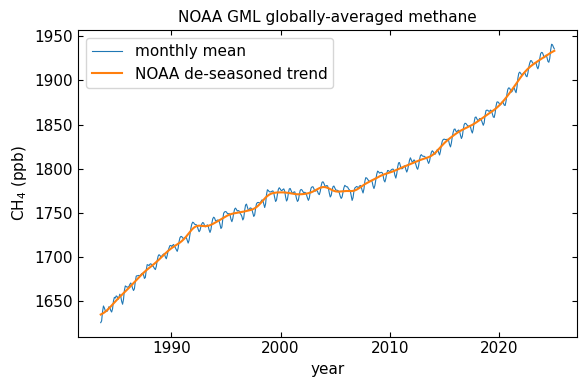

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["decimal"], df["average"], lw=0.8, label="monthly mean")
ax.plot(df["decimal"], df["trend"], lw=1.5, label="NOAA de-seasoned trend")
ax.set_xlabel("year")
ax.set_ylabel("CH$_4$ (ppb)")
ax.set_title("NOAA GML globally-averaged methane")
ax.legend()
ax.tick_params(which='both', direction='in', top=True, right=True)
plt.tight_layout()
plt.show()

## Part 1 — Time-Series Decomposition (8 pts)

### Task 1.1 — Seasonal-trend decomposition (4 pts)
Use `statsmodels.tsa.seasonal_decompose(df['average'], period=12, model='additive')`. Plot the four panels (observed, trend, seasonal, residual) stacked vertically.

### Task 1.2 — Seasonal amplitude (4 pts)
What is the peak-to-peak amplitude of the seasonal component? In which months does CH₄ peak and trough? Briefly (2–3 sentences) relate this to the OH-oxidation seasonal cycle.

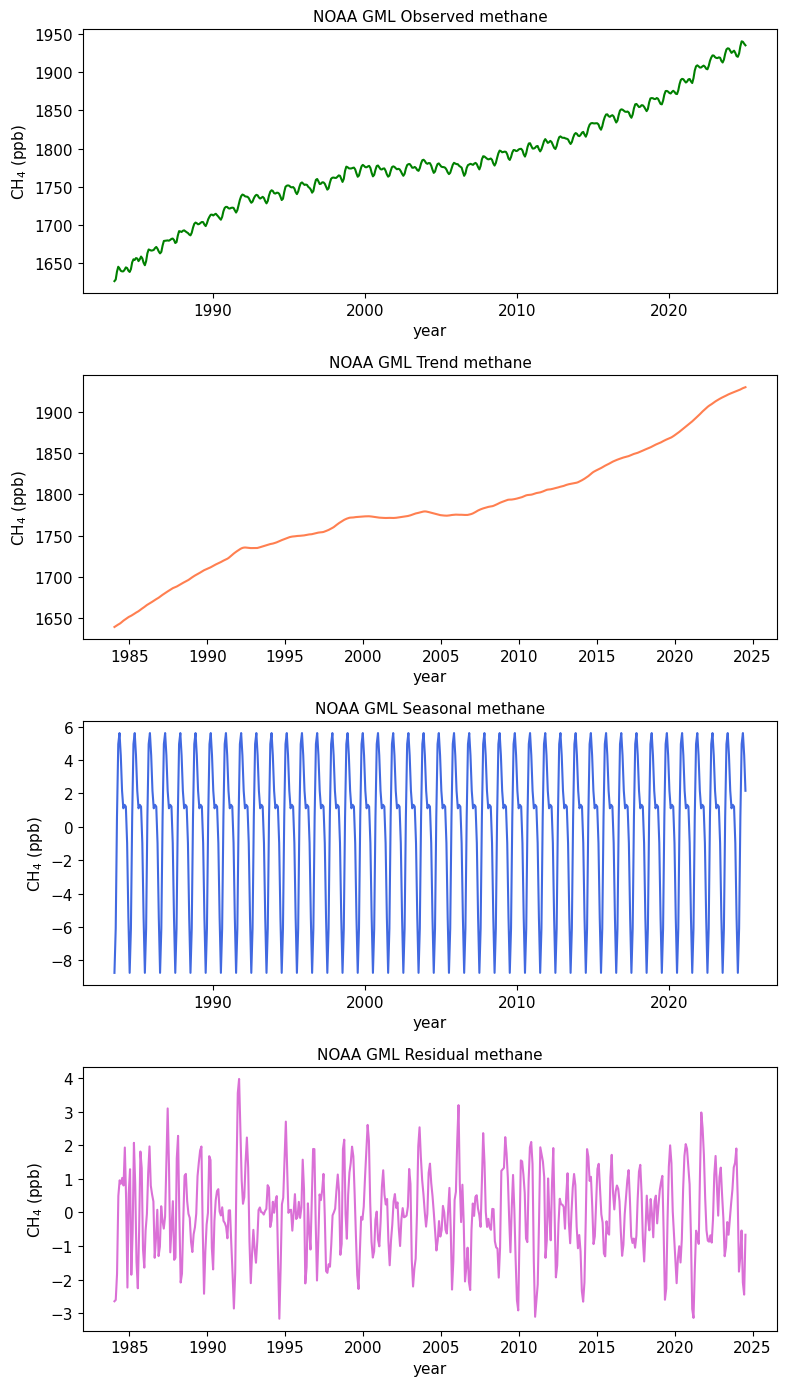

In [ ]:
# Part 1: your code here
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df['average'].values, period=12, model='additive')
fig, axes = plt.subplots(4,1, figsize=(8,14))
axes[0].plot(df['decimal'], decomp.observed,color='green',label='Observed')
axes[0].set_xlabel('year')
axes[0].set_ylabel('CH$_4$ (ppb)')
axes[0].set_title('NOAA GML Observed methane')

axes[1].plot(df['decimal'], decomp.trend,color='coral',label='Trend')
axes[1].set_xlabel('year')
axes[1].set_ylabel('CH$_4$ (ppb)')
axes[1].set_title('NOAA GML Trend methane')

axes[2].plot(df['decimal'], decomp.seasonal,color='royalblue',label='Seasonal')
axes[2].set_xlabel('year')
axes[2].set_ylabel('CH$_4$ (ppb)')
axes[2].set_title('NOAA GML Seasonal methane')

axes[3].plot(df['decimal'], decomp.resid,color='orchid',label='Residual')
axes[3].set_xlabel('year')
axes[3].set_ylabel('CH$_4$ (ppb)')
axes[3].set_title('NOAA GML Residual methane')

plt.tight_layout()

The peak to peak amplitude for the seasonal $CH_4$ emissions is roughly 14 ppb, with highs of around 6 ppb and lows of -8 ppb. The peaks seem to be at the very end of a year to the beginning of the next year, corresponding to the winter months.

## Part 2 — Parametric Fit (14 pts)

### Task 2.1 — Linear trend + single-harmonic seasonal (4 pts)
Fit the monthly mean to:
$$\mathrm{CH_4}(t) = a + b\,t + A\cos(2\pi t) + B\sin(2\pi t)$$
with $t$ in years (use the `decimal` column). Report the fitted parameters ± 1σ. Plot the fit over the data.

### Task 2.2 — Quadratic trend (4 pts)
Same model with $a + b t + c t^2$ instead of $a + b t$. Compare the residuals visually and via the root-mean-square error. Is the quadratic better? Does it capture the 1999–2006 plateau?

### Task 2.3 — Piecewise (change-point) trend (6 pts)
Fit a **three-segment** linear trend with change points at **1999.0** and **2007.0**, keeping the Fourier-series seasonal component. You can do this two ways:
- Hand-rolled: slice the DataFrame into three epochs and fit each separately.
- Joint fit: write a piecewise function and let `curve_fit` estimate the slopes simultaneously.

Report the three slopes (ppb/yr) with uncertainties. Do they match the textbook phases described in the Background section?

a = -9443.733 ± 7.801
b = 5.601 ± 0.004
A = 5.130 ± 0.064
B = -0.414 ± 0.062


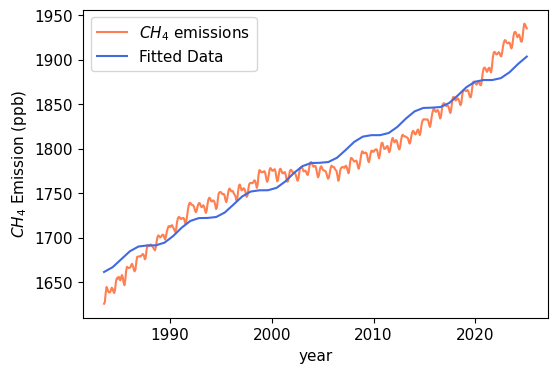

In [ ]:
# Part 2.1: your code here

def model_linear(t, a, b, A, B):
  '''
  Linear trend with single-harmonic seasonal component.

  Parameters
  ----------
  t : np.ndarray
      Time in decimal years.
  a : float
      Intercept (ppb).
  b : float
      Linear trend slope (ppb/yr).
  A : float
      Cosine amplitude of annual cycle (ppb).
  B : float
      Sine amplitude of annual cycle (ppb).

  Returns
  -------
  np.ndarray
      Modeled CH4 concentration (ppb) at each time t.
  '''
  return a + b*t + A*np.cos(2*np.pi*t) + B*np.sin(2*np.pi*t)

popt_lin, pcov_lin = curve_fit(model_linear, df['decimal'], df['average'], sigma=df['average_unc'], absolute_sigma=True)

perr = np.sqrt(np.diag(pcov_lin))

a_fit_lin, b_fit_lin, A_fit_lin, B_fit_lin = popt_lin

print(f"a = {a_fit_lin:.3f} ± {perr[0]:.3f}")
print(f"b = {b_fit_lin:.3f} ± {perr[1]:.3f}")
print(f"A = {A_fit_lin:.3f} ± {perr[2]:.3f}")
print(f"B = {B_fit_lin:.3f} ± {perr[3]:.3f}")

t_fit = np.linspace(df['decimal'].min(), df['decimal'].max())
y_fit = model_linear(t_fit, a_fit_lin, b_fit_lin, A_fit_lin, B_fit_lin)

plt.figure(figsize=(6,4))
plt.plot(df['decimal'],df['average'],label='$CH_4$ emissions',color='coral')
plt.plot(t_fit,y_fit,label='Fitted Data',color='royalblue')
plt.xlabel('year')
plt.ylabel('$CH_4$ Emission (ppb)')
plt.legend()
plt.show()

RMSE linear:  16.672537571688505
RMSE quadratic:  16.53628299614956


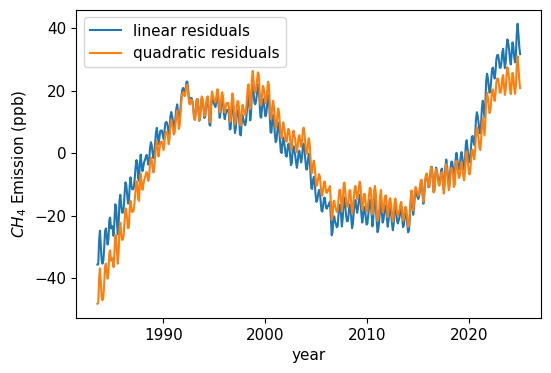

In [ ]:
#Part 2.2

def model_quad(t,a,b,c,A,B):
  '''
  Quadratic trend with single-harmonic seasonal component.

  Parameters
  ----------
  t : np.ndarray
      Time in decimal years.
  a : float
      Intercept (ppb).
  b : float
      Linear trend slope (ppb/yr).
  c: float
      Quadratic trend slope (ppb/year)
  A : float
      Cosine amplitude of annual cycle (ppb).
  B : float
      Sine amplitude of annual cycle (ppb).

  Returns
  -------
  np.ndarray
      Modeled CH4 concentration (ppb) at each time t.
  '''
  return a + b*t + c*t**2 + A*np.cos(2*np.pi*t) + B*np.sin(2*np.pi*t)

popt_quad, pcov_quad = curve_fit(model_quad, df['decimal'], df['average'], sigma=df['average_unc'], absolute_sigma=True)


#Residuals
res_linear = df['average'] - model_linear(df['decimal'], *popt_lin)
res_quad = df['average'] - model_quad(df['decimal'], *popt_quad)
#RMSE
rmse_linear = np.sqrt(np.mean(res_linear**2))
rmse_quad = np.sqrt(np.mean(res_quad**2))

print('RMSE linear: ', rmse_linear)
print('RMSE quadratic: ', rmse_quad)

plt.figure(figsize=(6,4))
plt.plot(df['decimal'], res_linear, label='linear residuals')
plt.plot(df['decimal'], res_quad, label='quadratic residuals')
plt.xlabel('year')
plt.ylabel('$CH_4$ Emission (ppb)')
plt.legend()
plt.show()

Visually, the residuals appear very similar, and comparing the values of the root-mean-square error, there is not a big difference between the two.

first slope:  8.111182975394831  ppb/year
second slope:  -0.9801510072898796  ppb/year
third slope:  8.50943248781293  ppb/year


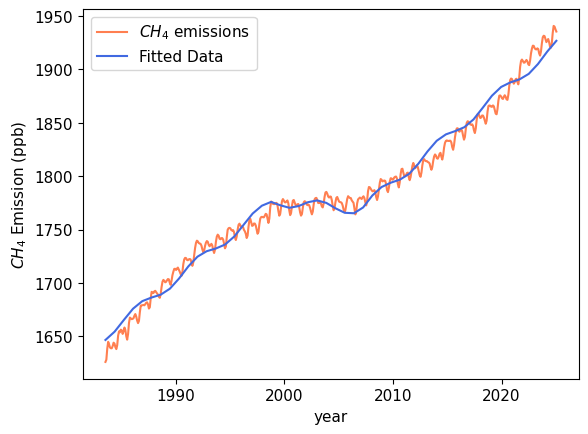

In [ ]:
#Part 2.3
def model_piecewise(t, a, b1, b2, b3, A, B):
  '''
  Piecewise trend with single-harmonic seasonal component.

  Parameters
  ----------
  t : np.ndarray
      Time in decimal years.
  a : float
      Intercept (ppb).
  b1 : float
      First section linear trend slope (ppb/yr).
  b2 : float
      Second section linear trend slope (ppb/yr).
  b3 : float
      Third section linear trend slope (ppb/yr).
  A : float
      Cosine amplitude of annual cycle (ppb).
  B : float
      Sine amplitude of annual cycle (ppb).

  Returns
  -------
  np.ndarray
      Modeled CH4 concentration (ppb) at each time t.
  '''

  t = np.asarray(t)

  y = np.zeros_like(t, dtype=float)

  mask1 = t < 1999
  mask2 = (t >= 1999) & (t < 2007)
  mask3 = t >= 2007

  #First section
  y[mask1] = a+b1*(t[mask1] - 1980)

  #Second section
  y1999 = a + b1 * (1999 - 1980)
  y[mask2] = y1999 + b2*(t[mask2] - 1999)

  #Third Section
  y2007 = y1999 + b2 * (2007 - 1999)
  y[mask3] = y2007 + b3*(t[mask3] - 2007)

  #Seasonal Component
  y += A*np.cos(2*np.pi*t)+B*np.sin(2*np.pi*t)

  return(y)

popt_piecewise, pcov_piecewise = curve_fit(model_piecewise, df['decimal'], df['average'], sigma=df['average_unc'], absolute_sigma=True)

a_fit, b1_fit, b2_fit, b3_fit, A_fit, B_fit = popt_piecewise

print('first slope: ', b1_fit, ' ppb/year')
print('second slope: ', b2_fit, ' ppb/year')
print('third slope: ', b3_fit, ' ppb/year')

y_fit = model_piecewise(t_fit,a_fit,b1_fit,b2_fit,b3_fit,A_fit,B_fit)

plt.plot(df['decimal'],df['average'],label='$CH_4$ emissions',color='coral')
plt.plot(t_fit,y_fit,label='Fitted Data',color='royalblue')
plt.xlabel('year')
plt.ylabel('$CH_4$ Emission (ppb)')
plt.legend()
plt.show()

Using the piecewise fit gives slopes as expected for the 1999-2006 plateau with an initial positive slope, though in this case of ~8.1ppb/year instead of the expected ~12ppb/year, then a plateau with a slope near 0ppb/year, then another positive slope.

## Part 3 — Extrapolation with Uncertainty (8 pts)

### Task 3.1 — Extrapolate each model to 2030 (4 pts)
Using the covariance matrix from `curve_fit`, propagate the parameter uncertainty to a **2030 CH₄ forecast** for each of your three models. Report central value ± 1σ and ± 2σ.

### Task 3.2 — Held-out cross-validation (4 pts)
Refit each model on data up through **2019** only. Predict 2020–2024 and compare to the actual values. Which model generalizes best? Plot forecast vs. actual with a shaded confidence band.

In [ ]:
# Part 3.1

t2030 = 2030

pred_lin = model_linear(t2030, *popt_lin)
pred_quad = model_quad(t2030, *popt_quad)
pred_piecewise = model_piecewise(t2030, *popt_piecewise)

#Jacobian
J_lin = np.array([1,t2030,np.cos(2*np.pi*t2030),np.sin(2*np.pi*t2030)])
J_quad = np.array([1,t2030,t2030**2,np.cos(2*np.pi*t2030),np.sin(2*np.pi*t2030)])
J_piecewise = np.array([1,(1999-1980),(2007-1999),(t2030-2007),np.cos(2*np.pi*t2030),np.sin(2*np.pi*t2030)])

#Uncertainty propagation
var_lin = J_lin @ pcov_lin @ J_lin.T
sigma_lin = np.sqrt(var_lin)
var_quad = J_quad @ pcov_quad @ J_quad.T
sigma_quad = np.sqrt(var_quad)
var_piecewise = J_piecewise @ pcov_piecewise @ J_piecewise.T
sigma_piecewise = np.sqrt(var_piecewise)

print(f"linear 2030 prediction: {pred_lin:.3f} ppb")
print(f"linear ±1σ: {pred_lin:.3f}±{sigma_lin:.3f} ppb")
print(f"linear ±2σ: {pred_lin:.3f}±{2*sigma_lin:.3f} ppb")
print() #Spacing
print(f"quadratic 2030 prediction: {pred_quad:.3f} ppb")
print(f"quadratic ±1σ: {pred_quad:.3f}±{sigma_quad:.3f} ppb")
print(f"quadratic ±2σ: {pred_quad:.3f}±{2*sigma_quad:.3f} ppb")
print() #Spacing
print(f"piecewise 2030 prediction: {pred_piecewise:.3f} ppb")
print(f"piecewise ±1σ: {pred_piecewise:.3f}±{sigma_piecewise:.3f} ppb")
print(f"piecewise ±2σ: {pred_piecewise:.3f}±{2*sigma_piecewise:.3f} ppb")

linear 2030 prediction: 1931.863 ppb
linear ±1σ: 1931.863±0.124 ppb
linear ±2σ: 1931.863±0.247 ppb

quadratic 2030 prediction: 1951.536 ppb
quadratic ±1σ: 1951.536±0.221 ppb
quadratic ±2σ: 1951.536±0.442 ppb

piecewise 2030 prediction: 1969.143 ppb
piecewise ±1σ: 1969.143±0.190 ppb
piecewise ±2σ: 1969.143±0.380 ppb


Linear test RMSE: 40.333 (ppb)
Linear train RMSE: 14.045 (ppb)

Quadratic test RMSE: 54.114 (ppb)
Quadratic train RMSE: 12.853 (ppb)

Piecewise test RMSE: 25.312 (ppb)
Piecewise train RMSE: 6.358 (ppb)


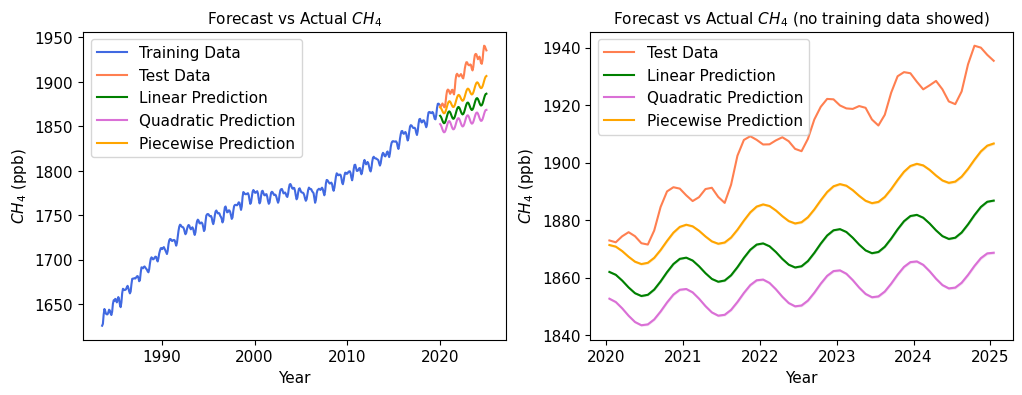

In [ ]:
#Part 3.2

train = df[df['decimal'] < 2020]
test = df[df['decimal'] >= 2020]

popt_train_lin, pcov_train_lin = curve_fit(model_linear, train['decimal'], train['average'], sigma=train['average_unc'], absolute_sigma=True)
popt_train_quad, pcov_train_quad = curve_fit(model_quad, train['decimal'], train['average'], sigma=train['average_unc'], absolute_sigma=True)
popt_train_piecewise, pcov_train_piecewise = curve_fit(model_piecewise, train['decimal'], train['average'], sigma=train['average_unc'], absolute_sigma=True)

y_lin = model_linear(test['decimal'], *popt_train_lin)
y_quad = model_quad(test['decimal'], *popt_train_quad)
y_piecewise = model_piecewise(test['decimal'], *popt_train_piecewise)

rmse_lin = np.sqrt(np.mean((test['average'] - y_lin)**2))
rmse_quad = np.sqrt(np.mean((test['average'] - y_quad)**2))
rmse_piecewise = np.sqrt(np.mean((test['average'] - y_piecewise)**2))


y_lin_train = model_linear(train['decimal'], *popt_train_lin)
y_quad_train = model_quad(train['decimal'], *popt_train_quad)
y_piecewise_train = model_piecewise(train['decimal'], *popt_train_piecewise)

rmse_lin_train = np.sqrt(np.mean((train['average'] - y_lin_train)**2))
rmse_quad_train = np.sqrt(np.mean((train['average'] - y_quad_train)**2))
rmse_piecewise_train = np.sqrt(np.mean((train['average'] - y_piecewise_train)**2))

print(f"Linear test RMSE: {rmse_lin:.3f} (ppb)")
print(f"Linear train RMSE: {rmse_lin_train:.3f} (ppb)")
print()
print(f"Quadratic test RMSE: {rmse_quad:.3f} (ppb)")
print(f"Quadratic train RMSE: {rmse_quad_train:.3f} (ppb)")
print()
print(f"Piecewise test RMSE: {rmse_piecewise:.3f} (ppb)")
print(f"Piecewise train RMSE: {rmse_piecewise_train:.3f} (ppb)")

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(train['decimal'], train['average'],color='royalblue',label='Training Data')
axes[0].plot(test['decimal'], test['average'],color='coral',label='Test Data')
axes[0].plot(test['decimal'], y_lin,color='green',label='Linear Prediction')
axes[0].plot(test['decimal'], y_quad,color='orchid',label='Quadratic Prediction')
axes[0].plot(test['decimal'], y_piecewise,color='orange',label='Piecewise Prediction')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('$CH_4$ (ppb)')
axes[0].set_title('Forecast vs Actual $CH_4$')
axes[0].legend()

axes[1].plot(test['decimal'], test['average'],color='coral',label='Test Data')
axes[1].plot(test['decimal'], y_lin,color='green',label='Linear Prediction')
axes[1].plot(test['decimal'], y_quad,color='orchid',label='Quadratic Prediction')
axes[1].plot(test['decimal'], y_piecewise,color='orange',label='Piecewise Prediction')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('$CH_4$ (ppb)')
axes[1].set_title('Forecast vs Actual $CH_4$ (no training data showed)')
axes[1].legend()

plt.show()

The piecewise fit both visually is closest to the test data, and has the smallest root-mean-square error, so its fit is the best of the three.

## Part 4 — Machine Learning Benchmark (8 pts)

### Task 4.1 — Lagged-feature Multi-Layer Perceptron (5 pts)
Build features from **lags** of the series: for each target month, use CH₄ values from 1, 2, 3, 6, and 12 months earlier. Train sklearn's `MLPRegressor` (same Multi-Layer Perceptron you used in HW6, just switched to regression) with two hidden layers of 32 units each. Report root-mean-square error on a held-out test split.

### Task 4.2 — Comparison (3 pts)
Put all four models (linear+seasonal, quadratic+seasonal, piecewise+seasonal, `MLPRegressor`) side-by-side in a summary table:

| Model | Train RMSE (ppb) | Test RMSE (ppb) | 2030 forecast (ppb) | 2030 ±1σ |
|-------|------------------|-----------------|---------------------|----------|
| ...   |                  |                 |                     |          |

Which model do you trust most for the 2030 forecast, and why?

In [ ]:
# Part 4.1
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

lags = [1,2,3,6,12]

X = []
y = []
dates = []

for i in range(max(lags), len(df['average'].values)):

  features = [df['average'].values[i-l] for l in lags]

  X.append(features)
  y.append(df['average'].values[i])
  dates.append(df['decimal'].values[i])

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

X_train = X[dates < 2020]
X_test = X[dates >= 2020]

y_train = y[dates < 2020]
y_test = y[dates >= 2020]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

MLP = MLPRegressor(hidden_layer_sizes=(32, 32), max_iter=4000)

MLP.fit(X_train_scaled, y_train)

train_pred = MLP.predict(X_train_scaled)
test_pred = MLP.predict(X_test_scaled)

rmse_MLP_train = np.sqrt(np.mean((y_train - train_pred)**2))
rmse_MLP_test = np.sqrt(np.mean((y_test - test_pred)**2))

print(f"Train RMSE = {rmse_MLP_train:.3f} ppb")
print(f"Test RMSE  = {rmse_MLP_test:.3f} ppb")

plt.figure(figsize=(6,4))

plt.plot(dates[dates >= 2020],y_test,label='Observed',color='royalblue')
plt.plot(dates[dates >= 2020], test_pred,label='MLP Prediction',color='coral')
plt.xlabel("Year")
plt.ylabel("CH$_4$ (ppb)")
plt.title("MLP Methane Forecast")
plt.legend()
plt.show()

## Part 4.2

| Model | Train RMSE (ppb) | Test RMSE (ppb) | 2030 forecast (ppb) | 2030 ±1σ |
|-------|------------------|-----------------|---------------------|----------|
|Linear | 14.045 | 40.333 |1931.863| ±0.124 |
|Quadratic | 12.853 | 54.114 | 1951.536 | ±0.221 |
|Piecewise | 6.358 | 25.312 | 1969.143 | ±0.190 |
|MLPRegressor | 2.927 | 204.909 | ... | ... |


Since Methane growth has changed over time in non-linear ways, such as the plateau from 1999 to 2007. The piecewise and MLPRegressor are the best ways to model methane to predict the 2030 forecast. Only the piecewise and MLP are able to acount for the plateau. which ignoring would throw off predictions, especially in the long run. Additionally, the piecewise has a much lower test root-mean-square error, making it the better of the two.

## Part 5 — Physics Discussion (4 pts)

Write ~8 sentences addressing:
- Why does the naive linear (or quadratic) extrapolation fail? Tie your residual plot to the textbook plateau-then-re-acceleration story.
- The Multi-Layer Perceptron has no physical model baked in — how would it do on genuinely novel behavior, e.g. a sudden drop caused by policy action?
- If you include CO₂ as a second signal (bonus: load `statsmodels.datasets.co2`), which gas is easier to forecast and why?

### Stretch (optional, bonus 4 pts)
Compare CH₄ and CO₂ on the same plot. Align them on a common time axis and comment on the relative forecast uncertainty in 2030.

The linear and quadratic extrapolations can not account for a plateau in the middle of the curve. These curves will be thrown off from the data by the plateau and it will require a piecewise curve, which allows for a section of little to no slope, to be able to accurately extrapolate. The multi-layer model would be unable to predict a novel drop, however, it would be able to more accurately analyze the conditions around previous unexpected changes, like the 1999-2007 plateau, so would have a better understanding of past novel changes, and could potentially pick up a pattern about its change to predict a similar event in the future, a naive extrapolation would have no chance of doing that. Including $CO_2$ would make for an easier gas to forecast. NOAA began recording the $CO_2$ data before the $CH_4$, and so the dataset has more entries. This means there would be more data to train an machine learning model or naive extrapolation model on, leading to more accurate forecasting. Additionally, the $CO_2$ data follows a more linear or quadratic trend, with no major plateau, meaning even the simpler extrapolations could make a more accurate forecast than on the $CH_4$ dataset.

## Submission
**Good commit** ✅: `Add piecewise trend fit with three change points`

**Bad commit** ❌: `done`, `update`

### Checklist
- [x] Notebook in `2026/FinalProject/<yourname>/`
- [ ] Runs top-to-bottom on a fresh kernel
- [ ] Functions have type annotations and NumPy docstrings
- [ ] All plots have labels with units; residual plots shown for each fit
- [ ] Tasks sum to ~42 points
- [ ] PR into `Homework2026`, reviewer `@laserlab`, milestone `Final-2026`
- [ ] AI usage disclosed in the PR

## Resources
- [NOAA GML methane trends page](https://gml.noaa.gov/ccgg/trends_ch4/)
- [`statsmodels.tsa.seasonal_decompose`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html)
- [`scipy.optimize.curve_fit`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)
- [`sklearn.neural_network.MLPRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)
- Dlugokencky et al. (1994), *Atmospheric methane at Mauna Loa and Barrow observatories*, JGR 99.